In [1]:
"""
BCI Motor Imagery Classification Pipeline (DataFrame-based)
Scope requested: Processing -> EDA -> CSP + SVM Modeling -> Evaluation
(No second model / no EEGNet, No deployment)

Design note: the dataset is kept as pandas DataFrames end-to-end.
- Long-format DataFrames (one row per time sample) hold every processing stage.
- A trial-level DataFrame ("trials_df") has one row per trial and a 'data' column
  whose cells are themselves per-trial DataFrames (time x channel). This lets
  scikit-learn's cross-validation splitters index trials (rows) directly while
  each trial's multichannel signal stays a DataFrame, never a bare 3D array.
- Small .values calls only happen transiently inside the linear-algebra steps
  of CSP (covariance / eigendecomposition), which is unavoidable for matrix math.
"""

'\nBCI Motor Imagery Classification Pipeline (DataFrame-based)\nScope requested: Processing -> EDA -> CSP + SVM Modeling -> Evaluation\n(No second model / no EEGNet, No deployment)\n\nDesign note: the dataset is kept as pandas DataFrames end-to-end.\n- Long-format DataFrames (one row per time sample) hold every processing stage.\n- A trial-level DataFrame ("trials_df") has one row per trial and a \'data\' column\n  whose cells are themselves per-trial DataFrames (time x channel). This lets\n  scikit-learn\'s cross-validation splitters index trials (rows) directly while\n  each trial\'s multichannel signal stays a DataFrame, never a bare 3D array.\n- Small .values calls only happen transiently inside the linear-algebra steps\n  of CSP (covariance / eigendecomposition), which is unavoidable for matrix math.\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from scipy.linalg import eigh
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)
import json, os
%matplotlib inline

In [3]:
OUT = r"C:\Users\USER\Downloads"
os.makedirs(OUT, exist_ok=True)

RANDOM_STATE = 42
FS = 160.0  # Hz, derived from time step (0.00625 s)

# ----------------------------------------------------------------------
# 1. LOAD & ORGANIZE  (stays a long-format DataFrame)
# ----------------------------------------------------------------------
df = pd.read_csv(r"C:\Users\USER\Downloads\eeg_hands_df.csv", index_col=0)
df = df.sort_values(["trial_id", "time"]).reset_index(drop=True)

import numpy as np
import pandas as pd
from scipy import stats

# 1. تجميع البيانات بناءً على الـ trial_id 
# الأعمدة الفيزيائية فقط (بدون trial_id و time)
channels = [col for col in df.columns if col not in ['trial_id', 'time', 'run', 'subject', 'label']]

trial_stds = []
trial_ids = df['trial_id'].unique()

# حساب الانحراف المعياري لكل Trial عبر كل القنوات
for t_id in trial_ids:
    trial_data = df[df['trial_id'] == t_id][channels].to_numpy()
    trial_stds.append(np.std(trial_data))

trial_stds = np.array(trial_stds)

# 2. حساب الـ Z-score لكل Trial
z_scores = np.abs(stats.zscore(trial_stds))

# تحديد حد الفلترة (3 انحرافات معيارية يعتبر معياراً ممتازاً لتوزيع بياناتك)
good_trials = trial_ids[z_scores < 2.5]

# 3. تصفية الـ DataFrame الأصلي لإبقاء الـ Trials النظيفة فقط
df = df[df['trial_id'].isin(good_trials)].reset_index(drop=True)

print(f"تم الحفاظ على {len(good_trials)} محاولة من أصل {len(trial_ids)} محاولات الكلية.")


ch_cols = [c for c in df.columns if c not in ["trial_id", "subject", "run", "label", "time"]]
n_channels = len(ch_cols)
n_trials = df["trial_id"].nunique()
n_times = df.groupby("trial_id").size().iloc[0]

trial_meta = df.groupby("trial_id").agg(label=("label", "first"), run=("run", "first")).reset_index()

log = {"n_trials": int(n_trials), "n_channels": n_channels, "n_times": int(n_times),
       "fs": FS, "channels": ch_cols,
       "class_counts": {k: int(v) for k, v in trial_meta["label"].value_counts().items()}}

تم الحفاظ على 87 محاولة من أصل 90 محاولات الكلية.


In [4]:
# ----------------------------------------------------------------------
# 2. PROCESSING - each stage is a full long-format DataFrame (copy of df)
# ----------------------------------------------------------------------
def bandpass_filter_df(long_df, low, high, fs=FS, order=4):
    """Zero-phase Butterworth band-pass, applied per trial, per channel,
    directly on a long-format DataFrame via groupby().transform-style loop."""
    b, a = butter(order, [low / (fs / 2), high / (fs / 2)], btype="band")
    out = long_df.copy()
    filtered_chunks = []
    for tid, g in out.groupby("trial_id", sort=False):
        g = g.copy()
        g[ch_cols] = filtfilt(b, a, g[ch_cols].to_numpy(), axis=0)
        filtered_chunks.append(g)
    return pd.concat(filtered_chunks, ignore_index=True)

# Step: Artifact rejection (peak-to-peak amplitude per trial, on raw signal)
ptp_by_trial = df.groupby("trial_id")[ch_cols].agg(lambda s: s.max() - s.min())
trial_ptp_max = ptp_by_trial.max(axis=1)
REJECT_THRESH = trial_ptp_max.quantile(0.99)
bad_trial_ids = trial_ptp_max[trial_ptp_max > REJECT_THRESH * 3].index.tolist()
log["artifact_rejection"] = {
    "threshold_uV_like": float(REJECT_THRESH * 3),
    "n_rejected": len(bad_trial_ids),
    "rejected_trial_idx": bad_trial_ids,
}
df = df[~df["trial_id"].isin(bad_trial_ids)].reset_index(drop=True)
trial_meta = trial_meta[~trial_meta["trial_id"].isin(bad_trial_ids)].reset_index(drop=True)
n_trials = df["trial_id"].nunique()

# Step: Band-pass filter 0.5-40 Hz (broad, remove drift/high-freq noise)
df_broad = bandpass_filter_df(df, 0.5, 40.0)

# Step: Notch filter - not applied: this dataset (PhysioNet-style motor imagery, fs=160Hz)
# shows no dominant 50/60Hz line component within the 0.5-40Hz band of interest, so a
# generic notch is skipped to avoid distorting the band without evidence of contamination.

# Step: Re-referencing - Common Average Reference (CAR): subtract, per time sample,
# the mean across channels (row-wise mean across ch_cols).
df_car = df_broad.copy()
df_car[ch_cols] = df_car[ch_cols].sub(df_car[ch_cols].mean(axis=1), axis=0)

# Step: Baseline correction - center each trial/channel on its own mean over time
# (no separate pre-stimulus window exists in this dataset, so whole-trial centering is used)
df_bc = df_car.copy()
df_bc[ch_cols] = df_bc.groupby("trial_id")[ch_cols].transform(lambda s: s - s.mean())

# Step: Mu/Beta band isolation (8-30 Hz) - the band CSP will operate on
df_mu_beta = bandpass_filter_df(df_bc, 8.0, 30.0)

df_mu_beta.to_csv(os.path.join(OUT, "processed_8_30hz_long.csv"), index=False)
trial_meta.to_csv(os.path.join(OUT, "trial_labels.csv"), index=False)

In [5]:
# ----------------------------------------------------------------------
# Build the trial-level DataFrame: one row per trial, 'data' cell = a
# (time x channel) DataFrame for that trial. Everything stays tabular.
# ----------------------------------------------------------------------
def to_trials_df(long_df, meta):
    rows = []
    for tid, g in long_df.groupby("trial_id", sort=False):
        rows.append({"trial_id": tid, "data": g.sort_values("time")[ch_cols].reset_index(drop=True)})
    data_df = pd.DataFrame(rows).merge(meta, on="trial_id").sort_values("trial_id").reset_index(drop=True)
    return data_df

trials_raw = to_trials_df(df, trial_meta)
trials_broad_car = to_trials_df(df_car, trial_meta)     # for EDA / PSD (broadband, CAR-referenced)
trials_mu_beta = to_trials_df(df_mu_beta, trial_meta)   # for CSP features

y_labels = trials_mu_beta["label"].to_numpy()
y = np.where(y_labels == "Right Hand", 1, 0)  # 1=Right, 0=Left

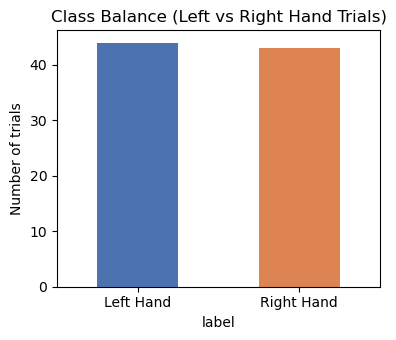

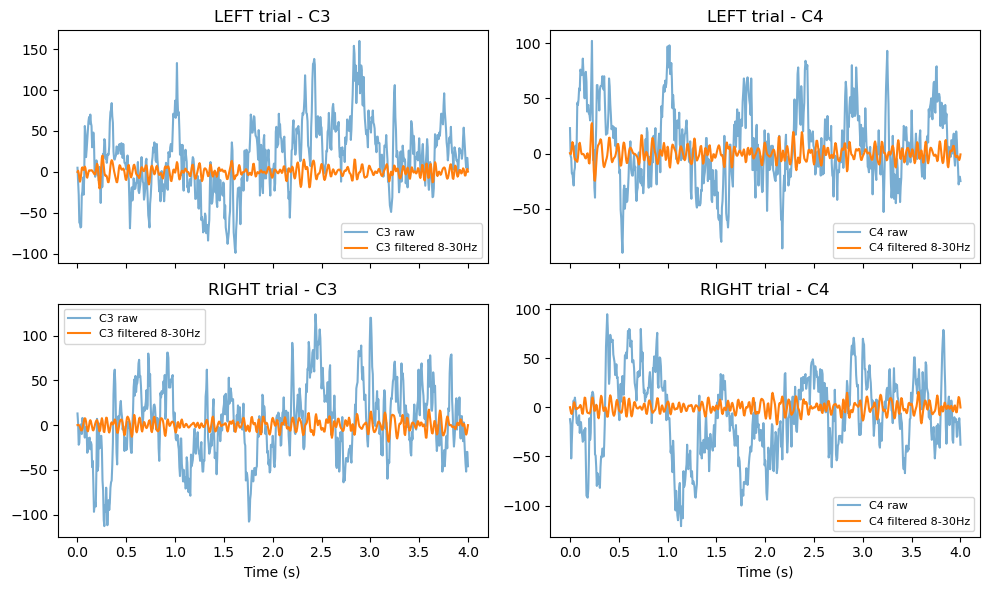

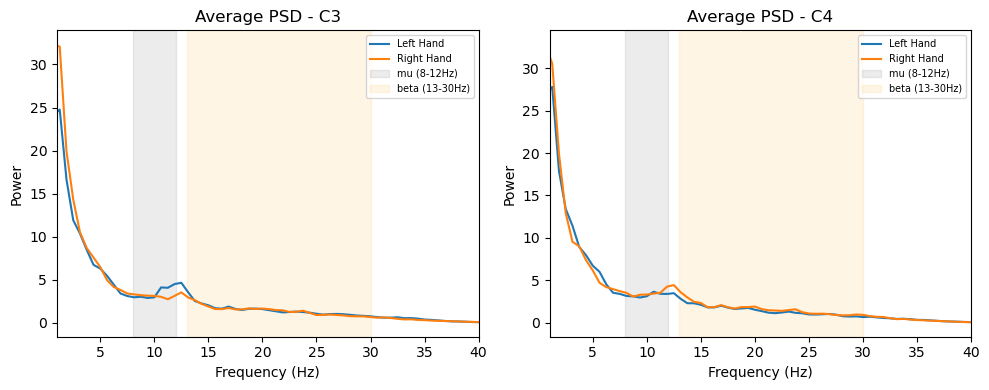

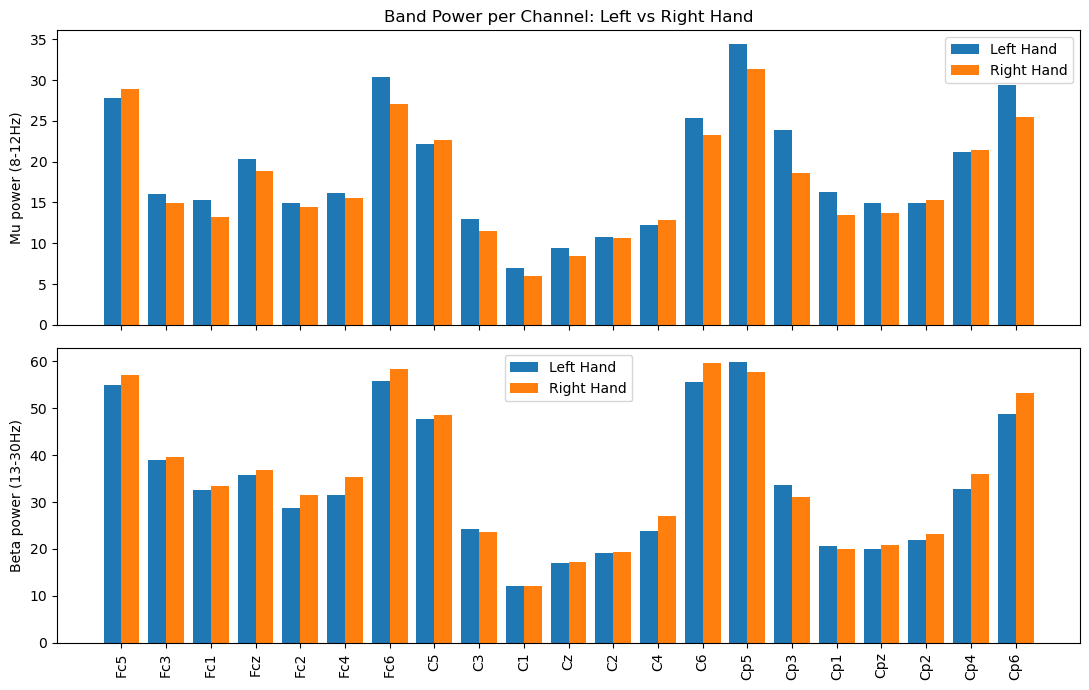

In [6]:
# ----------------------------------------------------------------------
# 3. EDA
# ----------------------------------------------------------------------
c3, c4 = "C3..", "C4.."

# 3.1 Class balance
plt.figure(figsize=(4, 3.5))
trial_meta["label"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Class Balance (Left vs Right Hand Trials)")
plt.ylabel("Number of trials")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "class_balance.png"), dpi=150)
#plt.close()
plt.show()
# 3.2 Time-domain example: one Left and one Right trial, C3 & C4, raw vs filtered
left_row = trials_raw[trials_raw["label"] == "Left Hand"].iloc[0]
right_row = trials_raw[trials_raw["label"] == "Right Hand"].iloc[0]
left_row_mu = trials_mu_beta[trials_mu_beta["trial_id"] == left_row["trial_id"]].iloc[0]
right_row_mu = trials_mu_beta[trials_mu_beta["trial_id"] == right_row["trial_id"]].iloc[0]
t = np.arange(n_times) / FS

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for row, (raw_row, mu_row, name) in enumerate([
        (left_row, left_row_mu, "LEFT trial"), (right_row, right_row_mu, "RIGHT trial")]):
    axes[row, 0].plot(t, raw_row["data"][c3], label="C3 raw", alpha=0.6)
    axes[row, 0].plot(t, mu_row["data"][c3], label="C3 filtered 8-30Hz")
    axes[row, 0].set_title(f"{name} - C3")
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].plot(t, raw_row["data"][c4], label="C4 raw", alpha=0.6)
    axes[row, 1].plot(t, mu_row["data"][c4], label="C4 filtered 8-30Hz")
    axes[row, 1].set_title(f"{name} - C4")
    axes[row, 1].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "time_domain_example.png"), dpi=150)
#plt.close()
plt.show()
# 3.3 PSD comparison (Welch) - Left vs Right, on C3 and C4 (CAR broadband signal)
def avg_psd(trials_df_subset, ch_name, fs=FS):
    psds = []
    for _, row in trials_df_subset.iterrows():
        f, p = welch(row["data"][ch_name].to_numpy(), fs=fs, nperseg=min(256, n_times))
        psds.append(p)
    return f, np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ch_name, title in [(axes[0], c3, "C3"), (axes[1], c4, "C4")]:
    f_l, p_l = avg_psd(trials_broad_car[trials_broad_car["label"] == "Left Hand"], ch_name)
    f_r, p_r = avg_psd(trials_broad_car[trials_broad_car["label"] == "Right Hand"], ch_name)
    ax.plot(f_l, p_l, label="Left Hand")
    ax.plot(f_r, p_r, label="Right Hand")
    ax.axvspan(8, 12, color="gray", alpha=0.15, label="mu (8-12Hz)")
    ax.axvspan(13, 30, color="orange", alpha=0.1, label="beta (13-30Hz)")
    ax.set_xlim(1, 40)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(f"Average PSD - {title}")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "psd_comparison.png"), dpi=150)
#plt.close()
plt.show()
# 3.4 Mu/Beta band power per channel per class -> stored as a tidy DataFrame
def bandpower_df(trials_df_subset, band, fs=FS):
    b_lo, b_hi = band
    records = []
    for _, row in trials_df_subset.iterrows():
        for ch in ch_cols:
            f, p = welch(row["data"][ch].to_numpy(), fs=fs, nperseg=min(256, n_times))
            mask = (f >= b_lo) & (f <= b_hi)
            records.append({"trial_id": row["trial_id"], "label": row["label"],
                             "channel": ch, "power": np.trapezoid(p[mask], f[mask])})
    return pd.DataFrame.from_records(records)

mu_power_df = bandpower_df(trials_broad_car, (8, 12))
beta_power_df = bandpower_df(trials_broad_car, (13, 30))

mu_mean = mu_power_df.groupby(["channel", "label"])["power"].mean().unstack()
beta_mean = beta_power_df.groupby(["channel", "label"])["power"].mean().unstack()
mu_mean = mu_mean.reindex(ch_cols)
beta_mean = beta_mean.reindex(ch_cols)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
x_pos = np.arange(n_channels)
axes[0].bar(x_pos - 0.2, mu_mean["Left Hand"], width=0.4, label="Left Hand")
axes[0].bar(x_pos + 0.2, mu_mean["Right Hand"], width=0.4, label="Right Hand")
axes[0].set_ylabel("Mu power (8-12Hz)")
axes[0].legend()
axes[0].set_title("Band Power per Channel: Left vs Right Hand")

axes[1].bar(x_pos - 0.2, beta_mean["Left Hand"], width=0.4, label="Left Hand")
axes[1].bar(x_pos + 0.2, beta_mean["Right Hand"], width=0.4, label="Right Hand")
axes[1].set_ylabel("Beta power (13-30Hz)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([c.strip('.') for c in ch_cols], rotation=90)
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "band_power_per_channel.png"), dpi=150)
#plt.close()
plt.show()
mu_power_df.to_csv(os.path.join(OUT, "mu_bandpower_by_trial.csv"), index=False)
beta_power_df.to_csv(os.path.join(OUT, "beta_bandpower_by_trial.csv"), index=False)

log["eda"] = {
    "c3_mu_power_left": float(mu_mean.loc[c3, "Left Hand"]), "c3_mu_power_right": float(mu_mean.loc[c3, "Right Hand"]),
    "c4_mu_power_left": float(mu_mean.loc[c4, "Left Hand"]), "c4_mu_power_right": float(mu_mean.loc[c4, "Right Hand"]),
    "c3_beta_power_left": float(beta_mean.loc[c3, "Left Hand"]), "c3_beta_power_right": float(beta_mean.loc[c3, "Right Hand"]),
    "c4_beta_power_left": float(beta_mean.loc[c4, "Left Hand"]), "c4_beta_power_right": float(beta_mean.loc[c4, "Right Hand"]),
}

In [7]:
# ----------------------------------------------------------------------
# 4 & 5. MODELING: CSP + SVM
# CSP is sklearn-compatible and operates on a pandas Series whose entries
# are per-trial (time x channel) DataFrames, so cross-validation splitters
# select trials (rows) while each trial itself stays a DataFrame.
# ----------------------------------------------------------------------
class CSP(BaseEstimator, TransformerMixin):
    """Common Spatial Patterns for binary classification.
    X: pandas Series, index aligned with y, each element a (time x channel) DataFrame.
    Output of transform: a DataFrame (index=X.index, columns=csp_1..csp_n).
    """
    def __init__(self, n_components=6, reg=1e-6):
        self.n_components = n_components
        self.reg = reg

    def _cov(self, trial_df):
        c = np.cov(trial_df.to_numpy().T)  # channels x channels
        c += self.reg * np.eye(c.shape[0])
        return c / np.trace(c)

    def fit(self, X, y):
        X = pd.Series(X) if not isinstance(X, pd.Series) else X
        y = np.asarray(y)
        classes = np.unique(y)
        assert len(classes) == 2, "CSP implemented for binary classification"
        self.channels_ = X.iloc[0].columns.tolist()
        cov0 = np.mean([self._cov(t) for t in X[y == classes[0]]], axis=0)
        cov1 = np.mean([self._cov(t) for t in X[y == classes[1]]], axis=0)
        eigvals, eigvecs = eigh(cov0, cov0 + cov1)
        order = np.argsort(eigvals)
        eigvecs = eigvecs[:, order]
        m = self.n_components // 2
        self.filters_ = np.concatenate([eigvecs[:, :m], eigvecs[:, -m:]], axis=1).T
        return self

    def transform(self, X):
        X = pd.Series(X) if not isinstance(X, pd.Series) else X
        feat_rows = []
        for trial_df in X:
            projected = self.filters_ @ trial_df[self.channels_].to_numpy().T
            var = np.var(projected, axis=1)
            feat_rows.append(np.log(var / np.sum(var)))
        cols = [f"csp_{i+1}" for i in range(self.filters_.shape[0])]
        return pd.DataFrame(feat_rows, index=X.index, columns=cols)

pipe = Pipeline([
    ("csp", CSP(n_components=6)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

param_grid = {
    "csp__n_components": [4, 6, 8],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__kernel": ["rbf", "linear"],
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring="accuracy", n_jobs=-1)

# X_trials: a pandas Series (default RangeIndex, aligned with y) of per-trial DataFrames.
X_trials = trials_mu_beta["data"].reset_index(drop=True)
y_series = pd.Series(y)

In [8]:
# ----------------------------------------------------------------------
# 4 & 5. MODELING: CSP + SVM
# CSP is sklearn-compatible and operates on a pandas Series whose entries
# are per-trial (time x channel) DataFrames, so cross-validation splitters
# select trials (rows) while each trial itself stays a DataFrame.
# ----------------------------------------------------------------------
class CSP(BaseEstimator, TransformerMixin):
    """Common Spatial Patterns for binary classification.
    X: pandas Series, index aligned with y, each element a (time x channel) DataFrame.
    Output of transform: a DataFrame (index=X.index, columns=csp_1..csp_n).
    """
    def __init__(self, n_components=6, reg=1e-6):
        self.n_components = n_components
        self.reg = reg

    def _cov(self, trial_df):
        c = np.cov(trial_df.to_numpy().T)  # channels x channels
        c += self.reg * np.eye(c.shape[0])
        return c / np.trace(c)

    def fit(self, X, y):
        X = pd.Series(X) if not isinstance(X, pd.Series) else X
        y = np.asarray(y)
        classes = np.unique(y)
        assert len(classes) == 2, "CSP implemented for binary classification"
        self.channels_ = X.iloc[0].columns.tolist()
        cov0 = np.mean([self._cov(t) for t in X[y == classes[0]]], axis=0)
        cov1 = np.mean([self._cov(t) for t in X[y == classes[1]]], axis=0)
        eigvals, eigvecs = eigh(cov0, cov0 + cov1)
        order = np.argsort(eigvals)
        eigvecs = eigvecs[:, order]
        m = self.n_components // 2
        self.filters_ = np.concatenate([eigvecs[:, :m], eigvecs[:, -m:]], axis=1).T
        return self

    def transform(self, X):
        X = pd.Series(X) if not isinstance(X, pd.Series) else X
        feat_rows = []
        for trial_df in X:
            projected = self.filters_ @ trial_df[self.channels_].to_numpy().T
            var = np.var(projected, axis=1)
            feat_rows.append(np.log(var / np.sum(var)))
        cols = [f"csp_{i+1}" for i in range(self.filters_.shape[0])]
        return pd.DataFrame(feat_rows, index=X.index, columns=cols)

pipe = Pipeline([
    ("csp", CSP(n_components=6)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

param_grid = {
    "csp__n_components": [4, 6, 8],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__kernel": ["rbf", "linear"],
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring="accuracy", n_jobs=-1)

# X_trials: a pandas Series (default RangeIndex, aligned with y) of per-trial DataFrames.
X_trials = trials_mu_beta["data"].reset_index(drop=True)
y_series = pd.Series(y)

# Nested CV: outer loop gives an unbiased performance estimate,
# inner GridSearchCV (within each outer-train fold) selects hyperparameters.
y_pred = cross_val_predict(grid, X_trials, y_series, cv=outer_cv, method="predict", n_jobs=-1)
y_proba = cross_val_predict(grid, X_trials, y_series, cv=outer_cv, method="predict_proba", n_jobs=-1)[:, 1]

# Fold-by-fold accuracy (for reporting variance across folds)
fold_scores = []
for tr_idx, te_idx in outer_cv.split(X_trials, y_series):
    grid.fit(X_trials.iloc[tr_idx], y_series.iloc[tr_idx])
    fold_scores.append(grid.best_estimator_.score(X_trials.iloc[te_idx], y_series.iloc[te_idx]))

# Fit final model on ALL data (for reference / to inspect best params) - not used for the
# reported evaluation metrics above, which come from nested cross-validation only.
grid.fit(X_trials, y_series)
best_params = grid.best_params_

# Save the CSP feature matrix (as a DataFrame) produced by the best full-data model, for inspection
csp_features_df = grid.best_estimator_.named_steps["csp"].transform(X_trials)
csp_features_df.insert(0, "trial_id", trials_mu_beta["trial_id"].to_numpy())
csp_features_df.insert(1, "label", y_labels)
csp_features_df.to_csv(os.path.join(OUT, "csp_features.csv"), index=False)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `Cal

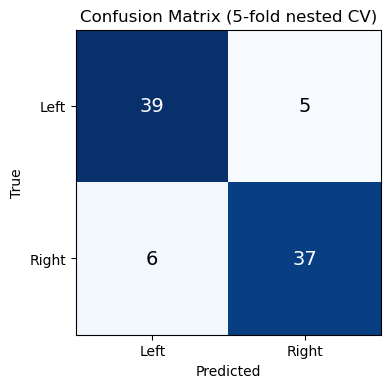

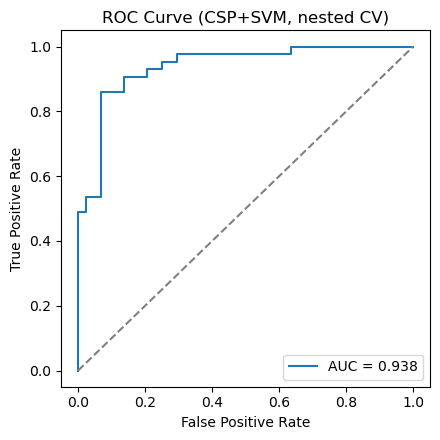

{
  "accuracy": 0.8735632183908046,
  "balanced_accuracy": 0.8734143763213531,
  "f1_score": 0.8705882352941177,
  "auc": 0.9381606765327695,
  "confusion_matrix": [
    [
      39,
      5
    ],
    [
      6,
      37
    ]
  ],
  "classification_report": "              precision    recall  f1-score   support\n\n   Left Hand       0.87      0.89      0.88        44\n  Right Hand       0.88      0.86      0.87        43\n\n    accuracy                           0.87        87\n   macro avg       0.87      0.87      0.87        87\nweighted avg       0.87      0.87      0.87        87\n"
}
{
  "method": "CSP + SVM",
  "csp_band_hz": [
    8,
    30
  ],
  "best_params_full_fit": {
    "csp__n_components": 4,
    "svm__C": 0.1,
    "svm__gamma": "scale",
    "svm__kernel": "rbf"
  },
  "outer_cv_folds": 5,
  "inner_cv_folds": 3,
  "fold_accuracies": [
    0.8888888888888888,
    0.8888888888888888,
    0.8823529411764706,
    0.8823529411764706,
    0.8235294117647058
  ],
  "fold_accu

In [9]:
# ----------------------------------------------------------------------
# 6. EVALUATION
# ----------------------------------------------------------------------
acc = accuracy_score(y, y_pred)
bal_acc = balanced_accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_proba)
cm = confusion_matrix(y, y_pred)
report_txt = classification_report(y, y_pred, target_names=["Left Hand", "Right Hand"])

preds_df = pd.DataFrame({
    "trial_id": trials_mu_beta["trial_id"].to_numpy(),
    "true_label": y_labels,
    "predicted_label": np.where(y_pred == 1, "Right Hand", "Left Hand"),
    "proba_right": y_proba,
})
preds_df.to_csv(os.path.join(OUT, "nested_cv_predictions.csv"), index=False)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Left", "Right"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Left", "Right"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (5-fold nested CV)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "confusion_matrix.png"), dpi=150)
#plt.close()
plt.show()

fpr, tpr, _ = roc_curve(y, y_proba)
plt.figure(figsize=(4.5, 4.5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CSP+SVM, nested CV)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "roc_curve.png"), dpi=150)
#plt.close()
plt.show()

log["modeling"] = {
    "method": "CSP + SVM",
    "csp_band_hz": [8, 30],
    "best_params_full_fit": best_params,
    "outer_cv_folds": 5,
    "inner_cv_folds": 3,
    "fold_accuracies": [float(s) for s in fold_scores],
    "fold_accuracy_mean": float(np.mean(fold_scores)),
    "fold_accuracy_std": float(np.std(fold_scores)),
}
log["evaluation"] = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "f1_score": float(f1),
    "auc": float(auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report_txt,
}


def _default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")


with open(os.path.join(OUT, "results.json"), "w") as f:
    json.dump(log, f, indent=2, default=_default)

print(json.dumps(log["evaluation"], indent=2))
print(json.dumps(log["modeling"], indent=2))
print("Class counts:", log["class_counts"])
print("Artifact rejection:", log["artifact_rejection"])

In [10]:
# ----------------------------------------------------------------------
# 7. SAVE FINAL MODEL (pickled)
# ----------------------------------------------------------------------
# Persist the best full-data CSP+Scaler+SVM pipeline (selected by GridSearchCV,
# see best_params above) so it can be reloaded later without re-running CV.
import pickle

model_path = os.path.join(OUT, "csp_svm_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)

print(f"Saved trained CSP+SVM pipeline to: {model_path}")
print(f"Best hyperparameters (full-data fit): {best_params}")

# Sanity check: reload and confirm it predicts
with open(model_path, "rb") as f:
    reloaded_model = pickle.load(f)

sanity_pred = reloaded_model.predict(X_trials.iloc[:5])
print("Reload OK - sample predictions:", sanity_pred)


Saved trained CSP+SVM pipeline to: C:\Users\USER\Downloads\csp_svm_model.pkl
Best hyperparameters (full-data fit): {'csp__n_components': 4, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Reload OK - sample predictions: [1 0 0 1 1]
